In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1: Imports and Setup
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
import os

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH    = "../data/jordan_population.csv"
SITES_PATH   = "../data/candidate_sites.csv"
OUT_PATH     = "../outputs"
FIG_PATH     = "../outputs/figures"

os.makedirs(OUT_PATH, exist_ok=True)
os.makedirs(FIG_PATH, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":      150,
    "font.family":     "serif",
    "font.size":       11,
    "axes.titlesize":  13,
    "axes.labelsize":  11,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})

COLORS = {
    "navy":   "#1B3A6B",
    "teal":   "#1A6B5A",
    "orange": "#E07B39",
    "red":    "#C0392B",
    "purple": "#6C3483",
    "gov":    ["#1B3A6B","#1A6B5A","#E07B39","#C0392B","#6C3483"],
}

print("✅ Cell 1 complete — libraries loaded")

✅ Cell 1 complete — libraries loaded


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2: Load and Inspect Data
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(DATA_PATH)

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Total demand points : {len(df)}")
print(f"  Columns             : {list(df.columns)}")
print(f"  Governorates        : {df['governorate'].unique().tolist()}")
print(f"  Missing values      : {df.isnull().sum().sum()}")
print("=" * 55)
print(f"\n  Population Summary:")
print(f"  Refugee pop  : {df['refugee_pop'].sum():>12,}")
print(f"  Host pop     : {df['host_pop'].sum():>12,}")
print(f"  Total pop    : {df['total_pop'].sum():>12,}")
print(f"\n  Vulnerability range: "
      f"{df['vulnerability'].min():.3f} – {df['vulnerability'].max():.3f}")
print(f"  Vulnerability mean : {df['vulnerability'].mean():.3f}")
print("=" * 55)

df.head(3)

  DATASET OVERVIEW
  Total demand points : 610
  Columns             : ['point_id', 'governorate', 'latitude', 'longitude', 'refugee_pop', 'host_pop', 'total_pop', 'vulnerability']
  Governorates        : ['Amman', 'Mafraq', 'Zarqa', 'Irbid', 'Azraq']
  Missing values      : 0

  Population Summary:
  Refugee pop  :      772,705
  Host pop     :    2,744,703
  Total pop    :    3,517,408

  Vulnerability range: 0.050 – 0.990
  Vulnerability mean : 0.630


,point_id,governorate,latitude,longitude,refugee_pop,host_pop,total_pop,vulnerability
0,0,Amman,31.455858,36.389334,624,474,1098,0.6378
1,1,Amman,31.938336,36.000190,2398,5087,7485,0.3174
2,2,Amman,32.638711,35.951951,175,2394,2569,0.5397


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3: Feature Engineering
# We cluster on 4 features:
#   latitude, longitude       → spatial position
#   log(total_pop)            → population density (log prevents large cities
#                               dominating the distance metric)
#   vulnerability             → humanitarian need
# Standardisation is mandatory before K-Means — the algorithm is
# distance-based and will otherwise be dominated by raw coordinate values
# ─────────────────────────────────────────────────────────────────────────────

df["log_total_pop"] = np.log1p(df["total_pop"])

FEATURES = ["latitude", "longitude", "log_total_pop", "vulnerability"]
X = df[FEATURES].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features prepared and standardised")
print(f"   Feature matrix shape : {X_scaled.shape}")
print(f"   Features used        : {FEATURES}")
print("\n   Standardised feature stats (mean ≈ 0, std ≈ 1):")
for i, f in enumerate(FEATURES):
    print(f"   {f:<20} mean={X_scaled[:,i].mean():+.4f}  "
          f"std={X_scaled[:,i].std():.4f}")

✅ Features prepared and standardised
   Feature matrix shape : (610, 4)
   Features used        : ['latitude', 'longitude', 'log_total_pop', 'vulnerability']

   Standardised feature stats (mean ≈ 0, std ≈ 1):
   latitude             mean=-0.0000  std=1.0000
   longitude            mean=-0.0000  std=1.0000
   log_total_pop        mean=-0.0000  std=1.0000
   vulnerability        mean=+0.0000  std=1.0000


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4: Silhouette Score Analysis — Finding Optimal k
# We test k = 5 to 15. For each k we compute:
#   Silhouette Score  → higher is better (max = 1.0)
#   Davies-Bouldin    → lower is better (min = 0.0)
#   Inertia (Elbow)   → lower is better
# Optimal k = highest silhouette score
# ─────────────────────────────────────────────────────────────────────────────

K_RANGE = range(5, 16)
results = []

print("Running K-Means across k = 5 to 15 ...")
print("-" * 50)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=20,
                max_iter=500, random_state=42)
    labels = km.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)
    inertia = km.inertia_

    results.append({
        "k":         k,
        "silhouette": round(sil, 4),
        "davies_bouldin": round(db, 4),
        "inertia":    round(inertia, 2),
    })
    print(f"  k={k:>2}  Silhouette={sil:.4f}  "
          f"Davies-Bouldin={db:.4f}  Inertia={inertia:.1f}")

results_df = pd.DataFrame(results)
optimal_k  = int(results_df.loc[results_df["silhouette"].idxmax(), "k"])

print("-" * 50)
print(f"\n  ✅ Optimal k = {optimal_k} "
      f"(Silhouette = "
      f"{results_df.loc[results_df['k']==optimal_k,'silhouette'].values[0]:.4f})")

Running K-Means across k = 5 to 15 ...
--------------------------------------------------
  k= 5  Silhouette=0.2145  Davies-Bouldin=1.3283  Inertia=1126.3
  k= 6  Silhouette=0.2009  Davies-Bouldin=1.3345  Inertia=1039.7
  k= 7  Silhouette=0.1953  Davies-Bouldin=1.3174  Inertia=967.7
  k= 8  Silhouette=0.2006  Davies-Bouldin=1.3097  Inertia=905.6
  k= 9  Silhouette=0.1941  Davies-Bouldin=1.3062  Inertia=860.4
  k=10  Silhouette=0.1860  Davies-Bouldin=1.3501  Inertia=822.3
  k=11  Silhouette=0.1840  Davies-Bouldin=1.3389  Inertia=784.4
  k=12  Silhouette=0.1809  Davies-Bouldin=1.3632  Inertia=749.7
  k=13  Silhouette=0.1788  Davies-Bouldin=1.3597  Inertia=723.3
  k=14  Silhouette=0.1868  Davies-Bouldin=1.3236  Inertia=691.9
  k=15  Silhouette=0.1802  Davies-Bouldin=1.2800  Inertia=670.0
--------------------------------------------------

  ✅ Optimal k = 5 (Silhouette = 0.2145)


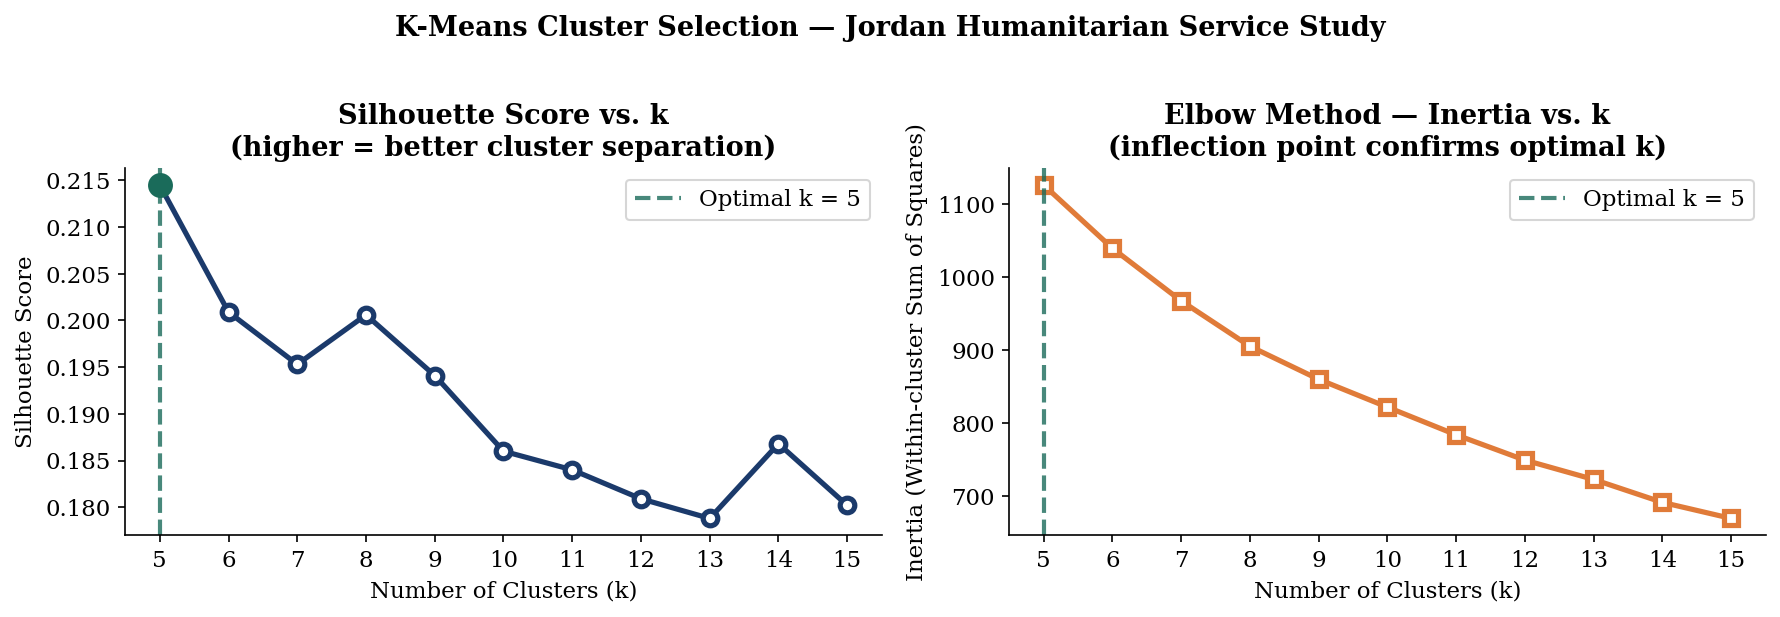

✅ Saved: ../outputs/figures/fig1a_silhouette_elbow.png


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5: Figure 1a — Silhouette Score Plot
# This figure goes directly into the paper as justification for k selection
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Silhouette Score
ax1 = axes[0]
ax1.plot(results_df["k"], results_df["silhouette"],
         marker="o", color=COLORS["navy"], linewidth=2.5,
         markersize=7, markerfacecolor="white", markeredgewidth=2.5)
ax1.axvline(x=optimal_k, color=COLORS["teal"], linestyle="--",
            linewidth=2, alpha=0.8, label=f"Optimal k = {optimal_k}")
ax1.scatter([optimal_k],
            [results_df.loc[results_df["k"]==optimal_k,
                            "silhouette"].values[0]],
            color=COLORS["teal"], s=120, zorder=5)
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Silhouette Score")
ax1.set_title("Silhouette Score vs. k\n(higher = better cluster separation)",
              fontweight="bold")
ax1.legend()
ax1.set_xticks(list(K_RANGE))

# Right: Elbow (Inertia)
ax2 = axes[1]
ax2.plot(results_df["k"], results_df["inertia"],
         marker="s", color=COLORS["orange"], linewidth=2.5,
         markersize=7, markerfacecolor="white", markeredgewidth=2.5)
ax2.axvline(x=optimal_k, color=COLORS["teal"], linestyle="--",
            linewidth=2, alpha=0.8, label=f"Optimal k = {optimal_k}")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Inertia (Within-cluster Sum of Squares)")
ax2.set_title("Elbow Method — Inertia vs. k\n(inflection point confirms optimal k)",
              fontweight="bold")
ax2.legend()
ax2.set_xticks(list(K_RANGE))

plt.suptitle("K-Means Cluster Selection — Jordan Humanitarian Service Study",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()

save_path = f"{FIG_PATH}/fig1a_silhouette_elbow.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {save_path}")

  CLUSTER SUMMARY
  Cluster 0:  167,940 people  (73,642 refugees, 94,298 hosts)  vuln=0.769
  Cluster 1:  712,438 people  (154,077 refugees, 558,361 hosts)  vuln=0.490
  Cluster 2:  977,440 people  (238,210 refugees, 739,230 hosts)  vuln=0.449
  Cluster 3:  166,807 people  (65,730 refugees, 101,077 hosts)  vuln=0.729
  Cluster 4: 1,492,783 people  (241,046 refugees, 1,251,737 hosts)  vuln=0.726


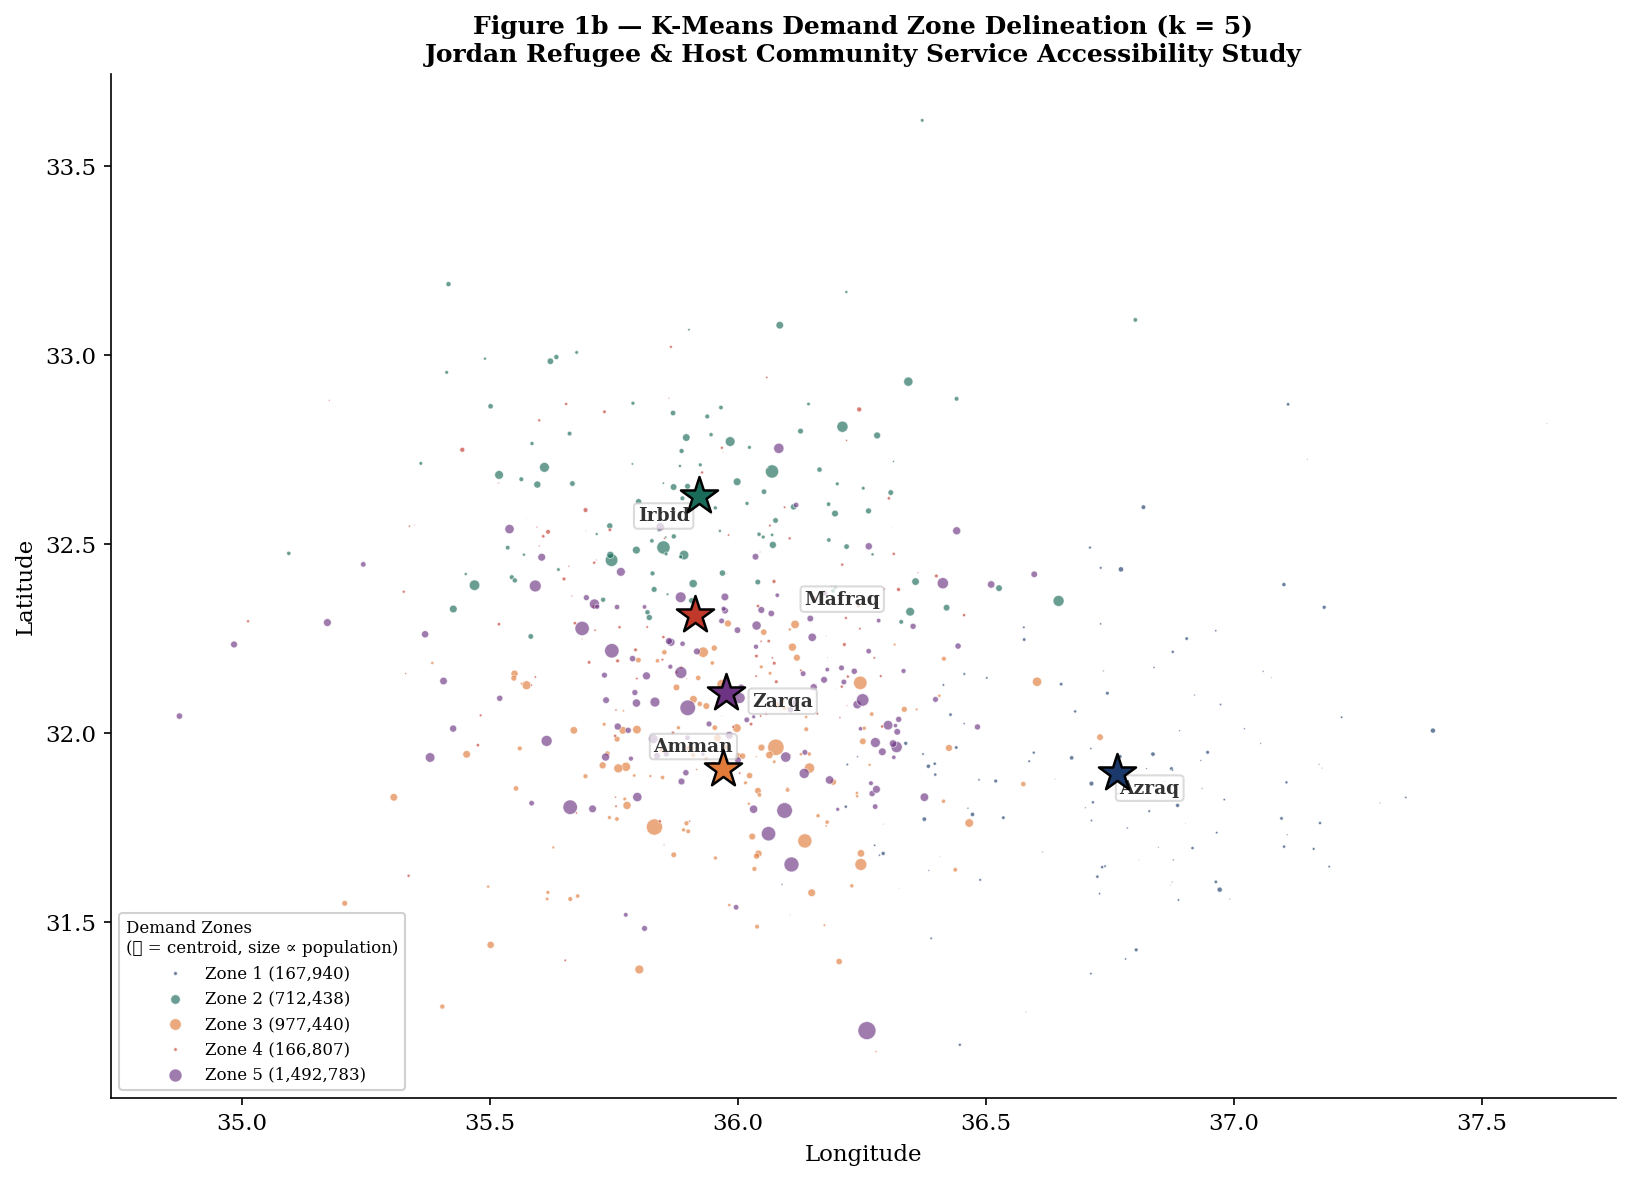

✅ Saved: ../outputs/figures/fig1b_cluster_map.png

✅ Block 2 complete — K-Means clustering done
   Optimal k = 5
   Files saved to /outputs/


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6: Final K-Means + Cluster Map (Figure 1b)
# ─────────────────────────────────────────────────────────────────────────────

# Fit final model
km_final = KMeans(n_clusters=optimal_k, init="k-means++",
                  n_init=30, max_iter=500, random_state=42)
df["cluster"] = km_final.fit_predict(X_scaled)

# Save cluster assignments
df.to_csv(f"{OUT_PATH}/jordan_population_clustered.csv", index=False)

# ── Cluster summary ────────────────────────────────────────────────────────
cluster_summary = df.groupby("cluster").agg(
    n_points       = ("point_id",      "count"),
    refugee_pop    = ("refugee_pop",   "sum"),
    host_pop       = ("host_pop",      "sum"),
    total_pop      = ("total_pop",     "sum"),
    mean_vuln      = ("vulnerability", "mean"),
    centroid_lat   = ("latitude",      "mean"),
    centroid_lon   = ("longitude",     "mean"),
).reset_index()

cluster_summary.to_csv(f"{OUT_PATH}/cluster_summary.csv", index=False)

print("  CLUSTER SUMMARY")
print("=" * 65)
for _, row in cluster_summary.iterrows():
    print(f"  Cluster {int(row['cluster'])}: "
          f"{int(row['total_pop']):>8,} people  "
          f"({int(row['refugee_pop']):,} refugees, "
          f"{int(row['host_pop']):,} hosts)  "
          f"vuln={row['mean_vuln']:.3f}")
print("=" * 65)

# ── Spatial plot ───────────────────────────────────────────────────────────
CLUSTER_COLORS = [
    "#1B3A6B","#1A6B5A","#E07B39","#C0392B","#6C3483",
    "#1A8C7A","#D4AC0D","#2874A6","#CB4335","#148F77",
    "#784212","#1F618D","#117A65","#884EA0","#B9770E"
][:optimal_k]

fig, ax = plt.subplots(figsize=(11, 8))

GOV_MARKERS = {
    "Amman": "o", "Mafraq": "s", "Zarqa": "^",
    "Irbid": "D", "Azraq": "P"
}

for cluster_id in range(optimal_k):
    mask = df["cluster"] == cluster_id
    sub  = df[mask]
    ax.scatter(sub["longitude"], sub["latitude"],
               c=CLUSTER_COLORS[cluster_id],
               s=sub["total_pop"] / 800,
               alpha=0.65, edgecolors="white", linewidth=0.4,
               label=f"Zone {cluster_id + 1} "
                     f"({cluster_summary.loc[cluster_id,'total_pop']:,})")

# Cluster centroids
centroids_orig = scaler.inverse_transform(km_final.cluster_centers_)
for i, c in enumerate(centroids_orig):
    ax.scatter(c[1], c[0], marker="*", s=350,
               color=CLUSTER_COLORS[i], edgecolors="black",
               linewidth=1.2, zorder=10)

# Governorate labels
GOV_LABEL_COORDS = {
    "Amman":  (35.91, 31.95),
    "Mafraq": (36.21, 32.34),
    "Zarqa":  (36.09, 32.07),
    "Irbid":  (35.85, 32.56),
    "Azraq":  (36.83, 31.84),
}
for gov, (x, y) in GOV_LABEL_COORDS.items():
    ax.text(x, y, gov, fontsize=9, fontweight="bold",
            color="#333333", ha="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                      alpha=0.7, edgecolor="#CCCCCC"))

ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude",  fontsize=11)
ax.set_title(
    f"Figure 1b — K-Means Demand Zone Delineation (k = {optimal_k})\n"
    "Jordan Refugee & Host Community Service Accessibility Study",
    fontsize=12, fontweight="bold"
)
ax.legend(title="Demand Zones\n(★ = centroid, size ∝ population)",
          loc="lower left", fontsize=8, title_fontsize=8,
          framealpha=0.9, edgecolor="#CCCCCC")

plt.tight_layout()
save_path = f"{FIG_PATH}/fig1b_cluster_map.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {save_path}")
print(f"\n✅ Block 2 complete — K-Means clustering done")
print(f"   Optimal k = {optimal_k}")
print(f"   Files saved to /outputs/")